# 1. Bibliotheken importieren

In [6]:
# Imports

import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os 

In [7]:
# Reproduzierbarkeit & Device

import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# GPU nutzen falls verfügbar - schneller damit das Training und die Inferenzsind, ansonsten CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seeds gesetzt: {SEED}")
print(f"Device: {device}") # gibt aus ob CPU oder GPU

Seeds gesetzt: 42
Device: cpu


# 2. Datensatz prüfen

In [8]:
# Datensatz prüfen

DATA_DIR = "../data"

#TODO: datenstruktur überprüfen -sinnvoll für andere wenn andere bezeichnung der ordner 
# expected_classes = ["cubism", "pop_art", "realism"]
# for split in ["train", "val", "test"]:
 #   split_path = os.path.join(DATA_DIR, split)
 #   assert os.path.exists(split_path), f"FEHLER: {split} Ordner fehlt!"
 #   for cls in expected_classes:
 #       cls_path = os.path.join(split_path, cls)
 #       assert os.path.exists(cls_path), f"FEHLER: Klasse {cls} fehlt in {split}!"
#print("Datenstruktur OK ✓")

# Klassen und Bildanzahl prüfen
for split in ["train", "val", "test"]:
    split_path = os.path.join(DATA_DIR, split)
    print(f"\n{split.upper()}:")
    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            count = len([
              f for f in os.listdir(class_path)
              if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            print(f"  {class_name}: {count} Bilder")


TRAIN:
  cubism: 1050 Bilder
  pop_art: 1038 Bilder
  realism: 1050 Bilder

VAL:
  cubism: 225 Bilder
  pop_art: 222 Bilder
  realism: 225 Bilder

TEST:
  cubism: 225 Bilder
  pop_art: 223 Bilder
  realism: 225 Bilder


# 3. Preprocessing definieren

In [9]:
# Preprocessing definieren

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms definiert:")
print(f"  Training:  {len(train_transform.transforms)} Schritte")
print(f"  Val/Test:  {len(val_test_transform.transforms)} Schritte")

Transforms definiert:
  Training:  4 Schritte
  Val/Test:  3 Schritte


# 4. Daten laden

In [ ]:

# Datensatz einlesen

train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "val"),
    transform=val_test_transform 
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=val_test_transform
    
)

# In Batches aufteilen

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Prüfen

print(f"Klassen: {train_dataset.classes}")
print(f"Klassen-Index: {train_dataset.class_to_idx}")
print(f"\nTraining: {len(train_dataset)} Bilder")
print(f"Validation: {len(val_dataset)} Bilder")
print(f"Test: {len(test_dataset)} Bilder")
print(f"\nBatches im Training: {len(train_loader)}")


Klassen: ['cubism', 'pop_art', 'realism']
Klassen-Index: {'cubism': 0, 'pop_art': 1, 'realism': 2}

Training: 3138 Bilder
Validation: 672 Bilder
Test: 673 Bilder

Batches im Training: 99


# 5. Modell aufbauen

In [11]:
# Vortrainiertes ResNet18 laden

model = models.resnet18(weights="IMAGENET1K_V1")

# Alle Layer einfrieren

for param in model.parameters():
    param.requires_grad = False

# Letzten Layer ersetzen - 3 Klassen statt 1000

num_classes = len(train_dataset.classes)
model.fc = torch.nn.Linear(512, num_classes)

# Prüfen

print(f"Modell geladen: ResNet18")
print(f"Anzahl Klassen: {num_classes}")
print(f"Klassen: {train_dataset.classes}")
print(f"\nLetzter Layer: {model.fc}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Lenovo PC/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Modell geladen: ResNet18
Anzahl Klassen: 3
Klassen: ['cubism', 'pop_art', 'realism']

Letzter Layer: Linear(in_features=512, out_features=3, bias=True)


# 6. Training konfigurieren

In [12]:
# Konfiguration

NUM_EPOCHS = 15                             # Anzahl der Epochen
LEARNING_RATE = 0.001                       # Lernrate

# Loss-Funktion: Misst wie falsch das Modell liegt

criterion = torch.nn.CrossEntropyLoss()

# Optimizer: Passt nur den letzten Layer an

optimizer = torch.optim.Adam(
    model.fc.parameters(),                  # nur den letzten LAyer
    lr=LEARNING_RATE                              
)

# Prüfen

print(f"Loss-Funktion: CrossEntropyLoss")
print(f"Optimizer: Adam (lr = {LEARNING_RATE})")
print(f"Epochen: {NUM_EPOCHS}")

Loss-Funktion: CrossEntropyLoss
Optimizer: Adam (lr = 0.001)
Epochen: 15


# 7. Trainingsschleife

In [13]:
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):

    # Training ---------------------------------------------------------------------------

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()                # 1. Alte Gradienten löschen
        outputs = model(images)              # 2. Bilder durch Modell schicken
        loss = criterion(outputs, labels)    # 3. Loss brechnen
        loss.backward()                      # 4. Gradient brechnen
        optimizer.step()                     # 5. Gewichte anpassen
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation --------------------------------------------------------------------------

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Ausgabe & Checkpoint ----------------------------------------------------------------

    print(f"Epoche {epoch+1:02}/{NUM_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "../model/best_model.pth") #ersetzten durch
        # TODO: gute gwohnheit- vielleicht nicht unbedingt bei unseren datensatz notwendig aber... : 
        # torch.save({
        #     'epoch': epoch,
        #     'model_state_dict': model.state_dict(),
        #     'optimizer_state_dict': optimizer.state_dict(),
        #     'loss': avg_val_loss,
        # }, "../model/best_model.pth")
        print(f"  → Checkpoint gespeichert!")

print("\nTraining abgeschlossen!")

Epoche 01/15 | Train Loss: 0.7085 | Val Loss: 0.4964
  → Checkpoint gespeichert!
Epoche 02/15 | Train Loss: 0.4744 | Val Loss: 0.4214
  → Checkpoint gespeichert!
Epoche 03/15 | Train Loss: 0.4345 | Val Loss: 0.4005
  → Checkpoint gespeichert!
Epoche 04/15 | Train Loss: 0.3905 | Val Loss: 0.3862
  → Checkpoint gespeichert!
Epoche 05/15 | Train Loss: 0.3779 | Val Loss: 0.3603
  → Checkpoint gespeichert!
Epoche 06/15 | Train Loss: 0.3694 | Val Loss: 0.3630
Epoche 07/15 | Train Loss: 0.3543 | Val Loss: 0.3681
Epoche 08/15 | Train Loss: 0.3706 | Val Loss: 0.3484
  → Checkpoint gespeichert!
Epoche 09/15 | Train Loss: 0.3734 | Val Loss: 0.3800
Epoche 10/15 | Train Loss: 0.3427 | Val Loss: 0.3613
Epoche 11/15 | Train Loss: 0.3276 | Val Loss: 0.3611
Epoche 12/15 | Train Loss: 0.3229 | Val Loss: 0.3592
Epoche 13/15 | Train Loss: 0.3385 | Val Loss: 0.3442
  → Checkpoint gespeichert!
Epoche 14/15 | Train Loss: 0.3445 | Val Loss: 0.3663
Epoche 15/15 | Train Loss: 0.3022 | Val Loss: 0.3421
  → Check

# 8. Kurven plotten

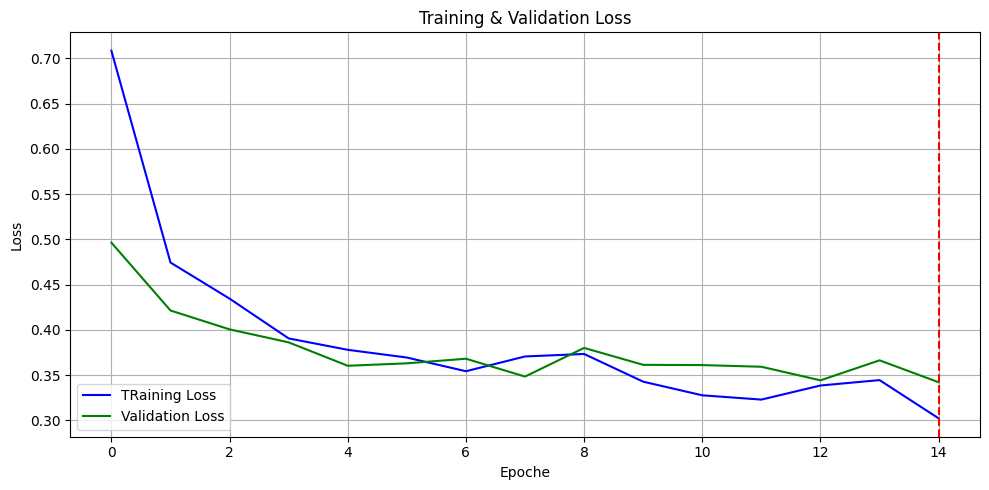


Bester Val Loss: 0.3421 bei Epoche 15


In [14]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="green")

plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)

# Besten Checkpoint markieren

best_epoch = val_losses.index(min(val_losses))
plt.axvline(x=best_epoch, color="red", linestyle="--", label=f"Bester Checkpoint (Epoche {best_epoch+1})")

plt.tight_layout()
plt.show()

print(f"\nBester Val Loss: {min(val_losses):.4f} bei Epoche {best_epoch+1}")


# 9. Test-Evaluation

Test Accuracy: 88.26%
Richtig:       594 von 673 Bildern
              precision    recall  f1-score   support

      cubism       0.86      0.84      0.85       225
     pop_art       0.88      0.83      0.85       223
     realism       0.90      0.97      0.94       225

    accuracy                           0.88       673
   macro avg       0.88      0.88      0.88       673
weighted avg       0.88      0.88      0.88       673



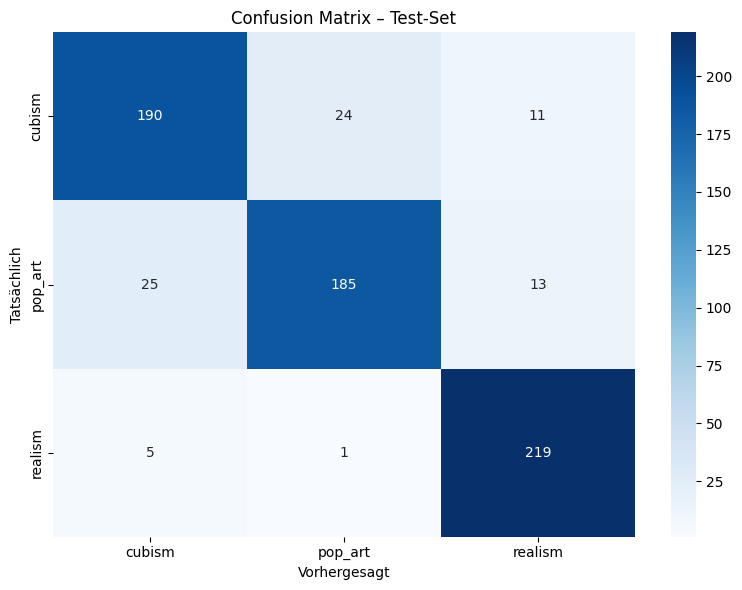

In [16]:

# Besten Checkpoint laden
model.load_state_dict(torch.load("../model/best_model.pth"))
#TODO: da oben verändert:
# checkpoint = torch.load("../model/best_model.pth")
# model.load_state_dict(checkpoint["model_state_dict"])
# print(f"Bestes Modell geladen – Epoche {checkpoint['epoch']+1}, "
#       f"Val Loss: {checkpoint['val_loss']:.4f}")
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total * 100

print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Richtig:       {correct} von {total} Bildern")

# TODO: erweitere metriken 

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds,
    target_names=train_dataset.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes,
            cmap="Blues")
plt.xlabel("Vorhergesagt")
plt.ylabel("Tatsächlich")
plt.title("Confusion Matrix – Test-Set")
plt.tight_layout()
plt.show()